In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
import torchvision
import torchvision.transforms as transforms
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

torch.manual_seed(42)

In [3]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

c:\Users\antag\AppData\Local\Programs\Python\Python313\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


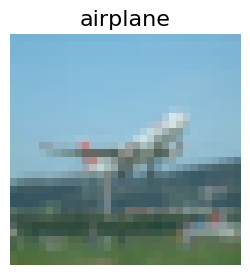

In [4]:
classes = train_dataset.classes

def show(img_tensor, lbl):
    img = img_tensor.permute(1, 2, 0)
    plt.figure(figsize=(3, 3))
    plt.title(classes[lbl], fontsize=16)
    plt.axis('off')
    plt.imshow(img)

rnd_idx = random.randint(0, len(train_dataset) - 1)
image, label = train_dataset[rnd_idx]
show(image, label)

In [5]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [6]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

In [7]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device)
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

In [8]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            x, y = x.to(device), y.to(device)
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc


In [9]:
def plot_learning_curves(train_losses, test_losses, train_accs, test_accs):
    epochs = range(1, len(train_losses) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, train_losses, label="Train Loss")
    ax1.plot(epochs, test_losses, label="Test Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss")
    ax1.legend()

    ax2.plot(epochs, train_accs, label="Train Accuracy")
    ax2.plot(epochs, test_accs, label="Test Accuracy")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [10]:
IMG_HEIGHT = 32
IMG_WIDTH = 32
IMG_CHANNELS = 3


Modelo 1

In [11]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(50, 75, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(75 * 4 * 4, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, len(classes))
)

model_cnn = model_cnn.to(device)


In [12]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

Training: 100%|██████████| 20/20 [03:52<00:00, 11.61s/epoch, train_acc=0.8796, train_loss=0.3365, val_acc=0.7457, val_loss=0.8916]


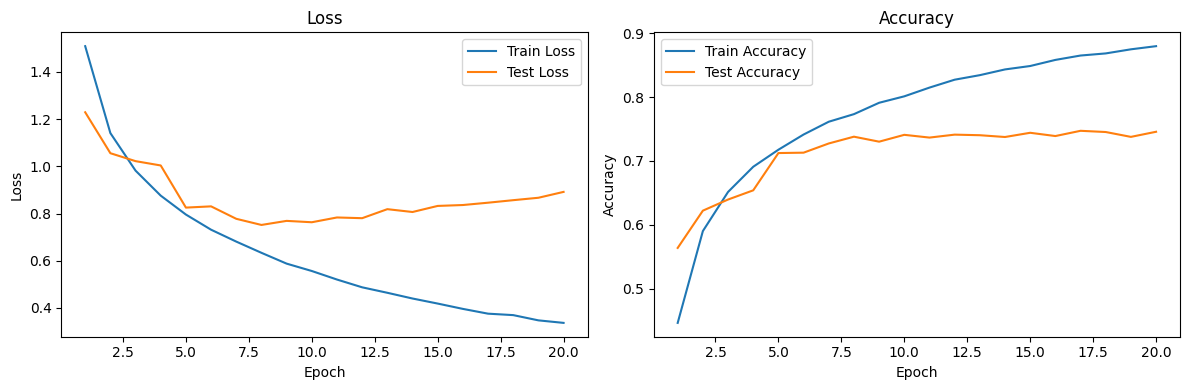

In [13]:
grafica_model_1 = plot_learning_curves(cnn_res['train_loss'], cnn_res['val_loss'], cnn_res['train_acc'], cnn_res['val_acc'])

Modelo 2

In [14]:
model2 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),    
    nn.ReLU(),
    nn.Conv2d(32, 32, 3, stride=1, padding=1),   
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    
    nn.Dropout(.2),

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),   
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    
    nn.Dropout(.3),

    nn.Conv2d(64, 128, 3, stride=1, padding=1), 
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),                    

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 512),
    nn.Dropout(.4),
    nn.ReLU(),
    nn.Linear(512, len(classes))
)

model2 = model2.to(device)

In [15]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model2.parameters())

cnn_res2 = train(model2, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss, cnn_test_acc = test(model2, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:40<00:00, 14.03s/epoch, train_acc=0.8021, train_loss=0.5591, val_acc=0.7876, val_loss=0.6473]


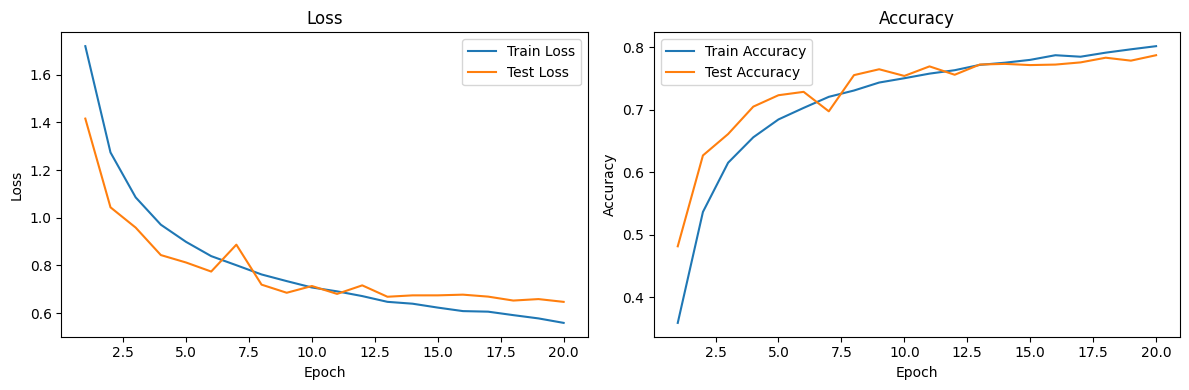

In [16]:
grafica_model_2 = plot_learning_curves(cnn_res2['train_loss'], cnn_res2['val_loss'], cnn_res2['train_acc'], cnn_res2['val_acc'])

Modelo 3

In [17]:
model3 = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 32, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Conv2d(32, 64, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.Dropout(.1),
    nn.MaxPool2d(2, stride=2), 

    nn.Conv2d(64, 128, 3, stride=1, padding=1),  
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  

    nn.Flatten(),
    nn.Linear(128 * 4 * 4, 1024),
    nn.Dropout(.2),
    nn.ReLU(),
    nn.Linear(1024, len(classes))
)

model3 = model3.to(device)

In [18]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model3.parameters())

cnn_res3 = train(model3, train_loader, test_loader, loss_function, optimizer, epochs)
cnn_test_loss3, cnn_test_acc3 = test(model3, test_loader, loss_function)

Training: 100%|██████████| 20/20 [04:18<00:00, 12.94s/epoch, train_acc=0.9547, train_loss=0.1353, val_acc=0.7315, val_loss=1.3496]


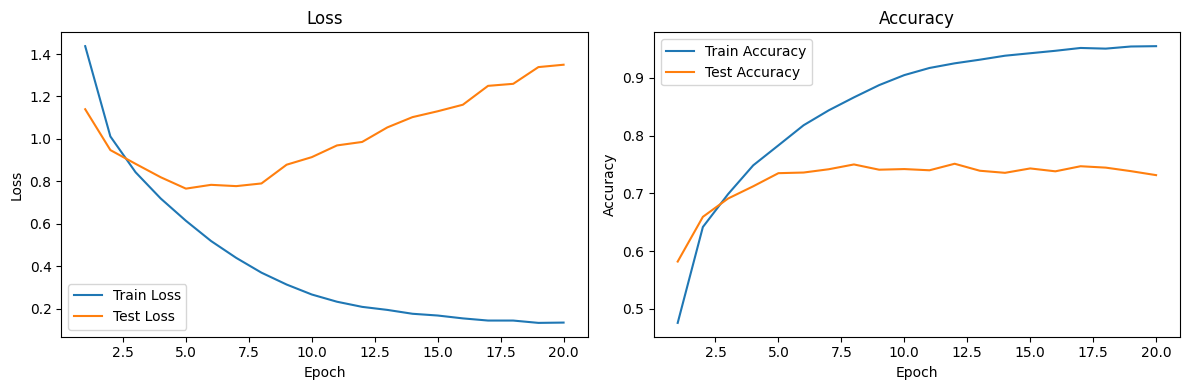

In [19]:
grafica_model_3 = plot_learning_curves(cnn_res3['train_loss'], cnn_res3['val_loss'], cnn_res3['train_acc'], cnn_res3['val_acc'])

In [20]:
m1_loss, m1_acc = test(model_cnn, test_loader, loss_function)
m2_loss, m2_acc = test(model2, test_loader, loss_function)
m3_loss, m3_acc = test(model3, test_loader, loss_function)

results = {
    "Modelo 1": {"loss": m1_loss, "accuracy": m1_acc},
    "Modelo 2": {"loss": m2_loss, "accuracy": m2_acc},
    "Modelo 3": {"loss": m3_loss, "accuracy": m3_acc},
}

print(f"{'Modelo':<12} {'Test Loss':>12} {'Test Accuracy':>15}")
print("-" * 42)
for name, metrics in results.items():
    print(f"{name:<12} {metrics['loss']:>12.4f} {metrics['accuracy']:>14.4f}")

best_model = max(results, key=lambda k: results[k]["accuracy"])
print(f"\nMejor modelo: {best_model} con accuracy = {results[best_model]['accuracy']:.4f}")


Modelo          Test Loss   Test Accuracy
------------------------------------------
Modelo 1           0.8916         0.7457
Modelo 2           0.6473         0.7876
Modelo 3           1.3496         0.7315

Mejor modelo: Modelo 2 con accuracy = 0.7876


In [21]:
def classify(image_path):
    model_map = {"Modelo 1": model_cnn, "Modelo 2": model2, "Modelo 3": model3}
    model = model_map[best_model]

    preprocess = transforms.Compose([
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
    ])

    img = Image.open(image_path).convert("RGB")
    tensor = preprocess(img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        pred = output.argmax(dim=1).item()

    label = classes[pred]

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.title(label, fontsize=16)
    plt.axis("off")
    plt.show()

    return label


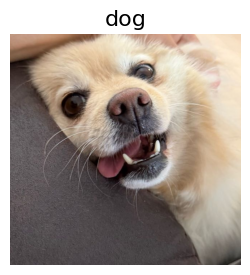

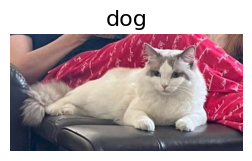

In [22]:
predicted_label = classify("perro2.jpeg")

pred_2 = classify("gato.jpeg")

Hacer uso de CNN para este dataset fue la decisión correcta, debido a que estan diseñadas para el procesamiento de imágenes, haciendo total uso de su capacidad para el manejo de datos con estructura espacial. 

Se crearon 3 modelos con estructuras e hiperparamétros diferentes para experimentar con el uso de estas redes, uno de estos alcanzaba valores de error muy grandes y con peor rendimiento que los demás, mientras que el segundo modelo fue mejor con diferencia y sin ser tan errática sus curvas de aprendizaje como los otros. El mejor modelo resultante tiene un rendimiento aceptable que podría mejorarse cambiando ciertos detalles de la implementación, pero que es suficiente para la actividad.